# Decision Tree Model Evaluation

This notebook trains and evaluates a **Decision Tree classifier** on the **processed credit default dataset** from the repository.

## Goal
Predict whether a client will **default next month** using the processed input features.

## Outputs required for the task
- **Accuracy**
- **ROC AUC**
- **PR AUC**
- **Confusion Matrix**
- **ROC Curve**
- **Precision-Recall Curve**
- **Calibration Curve**

## Data used
This notebook uses the already prepared files from `data/processed/`:
- `X_train.csv`, `X_val.csv`, `X_test.csv`
- `y_train.csv`, `y_val.csv`, `y_test.csv`

That means the notebook does **not** redo preprocessing. It works directly with the processed data split prepared in the project.


## 1. Import libraries

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve


## 2. Locate the processed dataset

The code below allows the notebook to run either:
- from the **repository root**, or
- from a `notebooks/` folder inside the repository.


In [5]:
# Run this notebook from the repo root or from notebooks/
current_dir = Path.cwd()

if (current_dir / 'data' / 'processed').exists():
    repo_root = current_dir
elif (current_dir.parent / 'data' / 'processed').exists():
    repo_root = current_dir.parent
else:
    raise FileNotFoundError('Could not find data/processed. Open the notebook from the repo root or notebooks folder.')

data_dir = repo_root / 'data' / 'processed'
data_dir

PosixPath('/Users/nurbekbauyrzhan/Desktop/ml-project-main/data/processed')

## 3. Load the processed train, validation, and test data

We load the feature matrices (`X`) and target vectors (`y`).

The target files should each contain exactly **one column**, which is converted into a 1D Series for scikit-learn.


In [7]:
X_train = pd.read_csv(data_dir / 'X_train.csv')
X_val = pd.read_csv(data_dir / 'X_val.csv')
X_test = pd.read_csv(data_dir / 'X_test.csv')

y_train = pd.read_csv(data_dir / 'y_train.csv')
y_val = pd.read_csv(data_dir / 'y_val.csv')
y_test = pd.read_csv(data_dir / 'y_test.csv')

# Convert target dataframes to 1D Series safely
if y_train.shape[1] == 1:
    y_train = y_train.iloc[:, 0]
else:
    raise ValueError('y_train.csv should contain exactly one target column.')

if y_val.shape[1] == 1:
    y_val = y_val.iloc[:, 0]
else:
    raise ValueError('y_val.csv should contain exactly one target column.')

if y_test.shape[1] == 1:
    y_test = y_test.iloc[:, 0]
else:
    raise ValueError('y_test.csv should contain exactly one target column.')

print('X_train:', X_train.shape)
print('X_val:  ', X_val.shape)
print('X_test: ', X_test.shape)
print('y_train:', y_train.shape)
print('y_val:  ', y_val.shape)
print('y_test: ', y_test.shape)

X_train: (21000, 3)
X_val:   (4500, 3)
X_test:  (4500, 3)
y_train: (21000,)
y_val:   (4500,)
y_test:  (4500,)


## 4. Quick data check

This section helps confirm:
- the target column name,
- the class distribution,
- and the number of feature columns.

This is useful because class imbalance can affect both **Accuracy** and **PR AUC**.


In [9]:
print('Target name:', y_train.name)
print('\nTraining target distribution:')
print(y_train.value_counts(dropna=False))

print('\nFirst 5 feature columns:')
print(X_train.columns[:5].tolist())
print('\nNumber of feature columns:', X_train.shape[1])

Target name: Y

Training target distribution:
Y
0    16355
1     4645
Name: count, dtype: int64

First 5 feature columns:
['X1', 'X6', 'X18']

Number of feature columns: 3


## 5. Train candidate Decision Tree models

A Decision Tree can easily overfit, so we try several simple parameter settings first.

### Why use validation data?
We train on the training set and compare candidate trees on the validation set. Then we choose the best setting before the final test evaluation.

### Parameters explored
- `max_depth`: limits how deep the tree can grow
- `min_samples_leaf`: forces a minimum number of samples in each leaf

These settings help reduce overfitting.


In [11]:
candidate_params = [
    {'max_depth': 3, 'min_samples_leaf': 20},
    {'max_depth': 4, 'min_samples_leaf': 20},
    {'max_depth': 5, 'min_samples_leaf': 20},
    {'max_depth': 6, 'min_samples_leaf': 20},
    {'max_depth': None, 'min_samples_leaf': 20},
    {'max_depth': 5, 'min_samples_leaf': 50},
    {'max_depth': 6, 'min_samples_leaf': 50},
    {'max_depth': None, 'min_samples_leaf': 50},
]

results = []

for params in candidate_params:
    model = DecisionTreeClassifier(
        random_state=42,
        **params
    )
    model.fit(X_train, y_train)
    val_proba = model.predict_proba(X_val)[:, 1]
    val_pred = model.predict(X_val)

    results.append({
        'params': params,
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_roc_auc': roc_auc_score(y_val, val_proba),
        'val_pr_auc': average_precision_score(y_val, val_proba),
    })

results_df = pd.DataFrame(results).sort_values(by='val_roc_auc', ascending=False)
results_df

,params,val_accuracy,val_roc_auc,val_pr_auc
6,"{'max_depth': 6, 'min_samples_leaf': 50}",0.812444,0.747952,0.496870
2,"{'max_depth': 5, 'min_samples_leaf': 20}",0.815556,0.747781,0.485717
5,"{'max_depth': 5, 'min_samples_leaf': 50}",0.814222,0.747428,0.486565
3,"{'max_depth': 6, 'min_samples_leaf': 20}",0.813778,0.747268,0.491719
1,"{'max_depth': 4, 'min_samples_leaf': 20}",0.816444,0.740282,0.468462
7,"{'max_depth': None, 'min_samples_leaf': 50}",0.813778,0.729936,0.495987
4,"{'max_depth': None, 'min_samples_leaf': 20}",0.806222,0.722973,0.469819
0,"{'max_depth': 3, 'min_samples_leaf': 20}",0.816444,0.716570,0.446363


## 6. Select the best Decision Tree and retrain on train + validation

After choosing the best validation setting, we combine the **training** and **validation** sets and fit one final model.

Then we evaluate that final model on the untouched **test set**.


In [13]:
best_params = results_df.iloc[0]['params']
print('Best validation params:', best_params)

X_train_full = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_full = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

final_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    **best_params
)
final_model.fit(X_train_full, y_train_full)

y_test_proba = final_model.predict_proba(X_test)[:, 1]

threshold = 0.35
y_test_pred = (y_test_proba >= threshold).astype(int)

Best validation params: {'max_depth': 6, 'min_samples_leaf': 50}


## 7. Final test metrics

### Metric meanings
- **Accuracy**: fraction of correctly classified examples
- **ROC AUC**: how well the model separates the two classes across thresholds
- **PR AUC**: how well the model balances precision and recall, especially useful when classes are imbalanced

These are the final reported numbers for the Decision Tree.


In [15]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print(f'Accuracy: {test_accuracy:.4f}')
print(f'ROC AUC:  {test_roc_auc:.4f}')
print(f'PR AUC:   {test_pr_auc:.4f}')
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred))

Accuracy: 0.5702
ROC AUC:  0.7456
PR AUC:   0.5028
              precision    recall  f1-score   support

           0       0.90      0.50      0.65      3504
           1       0.32      0.80      0.45       996

    accuracy                           0.57      4500
   macro avg       0.61      0.65      0.55      4500
weighted avg       0.77      0.57      0.60      4500



## 8. Confusion Matrix

The confusion matrix shows the number of:
- **True Negatives**
- **False Positives**
- **False Negatives**
- **True Positives**

This helps explain what kind of mistakes the model makes.


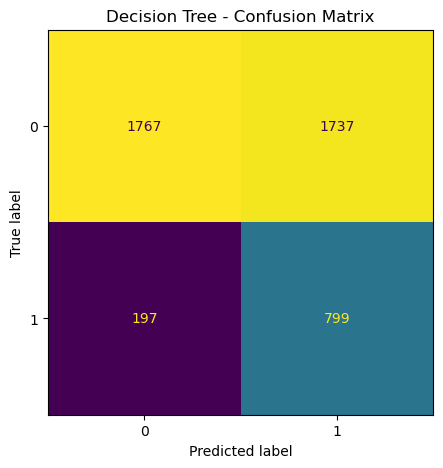

In [17]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False)
ax.set_title('Decision Tree - Confusion Matrix')
plt.show()

## 9. ROC Curve

The ROC curve plots:
- **True Positive Rate** on the y-axis
- **False Positive Rate** on the x-axis

The closer the curve is to the top-left corner, the better the classifier.


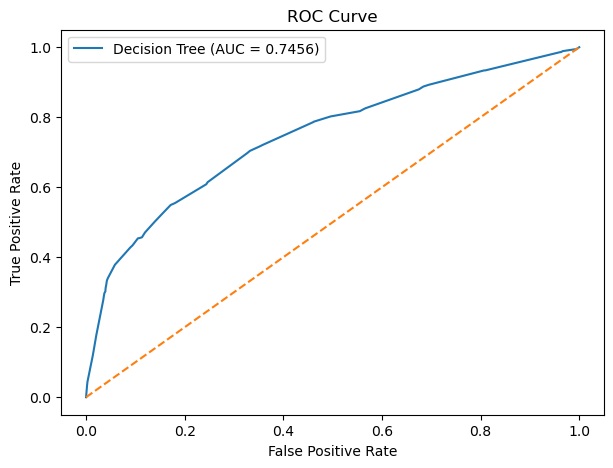

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## 10. Precision-Recall Curve

The PR curve plots:
- **Precision** on the y-axis
- **Recall** on the x-axis

This curve is especially informative when the positive class is less common.


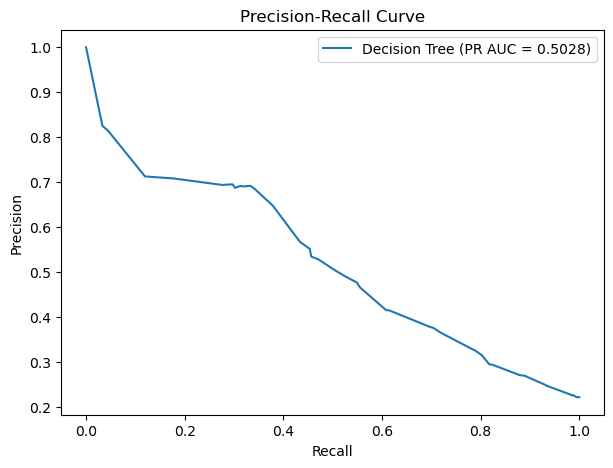

In [21]:
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'Decision Tree (PR AUC = {test_pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

## 11. Calibration Curve

A calibration curve checks whether predicted probabilities match real outcomes.

For example, if the model predicts a group of cases with probability 0.70, then about 70% of those cases should actually be positive for the model to be well calibrated.

The dashed line represents perfect calibration.


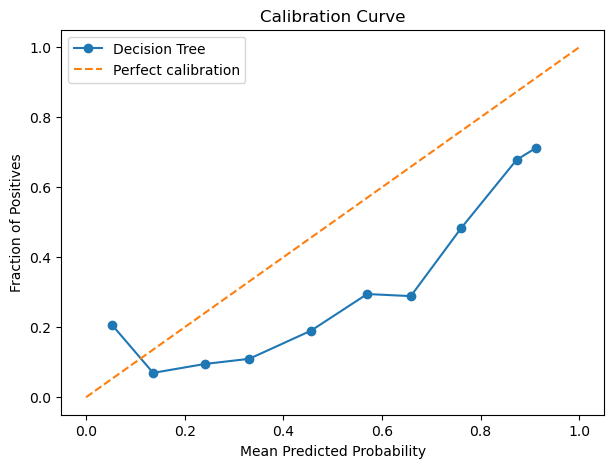

In [23]:
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10, strategy='uniform')

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker='o', label='Decision Tree')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

## 12. Summary table

This creates a compact table with the final results and chosen Decision Tree parameters.


In [25]:
metrics_df = pd.DataFrame([
    {
        'model': 'Decision Tree',
        'accuracy': test_accuracy,
        'roc_auc': test_roc_auc,
        'pr_auc': test_pr_auc,
        'best_params': str(best_params),
    }
])

metrics_df

,model,accuracy,roc_auc,pr_auc,best_params
0,Decision Tree,0.570222,0.745649,0.502846,"{'max_depth': 6, 'min_samples_leaf': 50}"


## 13. Short conclusion template

After running the notebook, you can replace the brackets below with your real values:

> The Decision Tree model achieved an **Accuracy** of **[value]**, **ROC AUC** of **[value]**, and **PR AUC** of **[value]** on the test set. The confusion matrix shows how the model distributes correct and incorrect predictions, while the ROC and PR curves summarize classification quality across thresholds. The calibration curve helps evaluate whether the predicted probabilities are reliable.

You can copy that paragraph directly into a report or presentation.
